In [1]:
import os
import sys
import time

PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

from src.augmentation.ollama import OllamaClient, paraphrase_title
from src.categorization.hft import HierarchicalFastText
from src.data.hierarchy import load_offers_with_levels
from src.data.prepare_data import TextPreprocessor
from src.evaluation import metrics as faithfulness
from src.evaluation.consistency import path_agreement, score_correlation, top_k_overlap
from src.evaluation.lime import LimeExplainer
from src.evaluation.viz import plot_word_importance

TRAIN_ROWS = 25000
ACC_TEST_N = 2000
FAITH_N = 25
CONSIST_N = 15
N_VARIANTS = 3
LIME_SAMPLES = 200
TOP_K = 5
SEED = 42

In [2]:
offers = load_offers_with_levels(
    "data/raw_data/full_dataset.csv",
    "data/raw_data/category_mapping.csv",
    max_level=4,
)
offers = offers.dropna(subset=["L1"]).sample(n=TRAIN_ROWS, random_state=SEED).reset_index(drop=True)

pre = TextPreprocessor()
offers["t"] = offers["text"].apply(pre.normalize)

split = int(len(offers) * 0.8)
train_df = offers.iloc[:split].reset_index(drop=True)
test_df = offers.iloc[split:].reset_index(drop=True)

print(f"train: {len(train_df)}  test: {len(test_df)}")
display(train_df[["text", "L1", "L2", "L3", "L4"]].head(5))
display(train_df["L1"].value_counts().head(10).to_frame("count"))

train: 20000  test: 5000


,text,L1,L2,L3,L4
0,2x 155/65/14 T Fulda MULTI CONTROL TOTAL,Automotive,Tires and Rims,Tires,For passenger cars
1,"NOTEBOOK LAPTOP 13,5"" 14"" BAG POUCH",Electronics,Computers,"Accessories (Laptop, PC)","Bags, Covers"
2,HUB NUT FRONT M60X2 FH12/FM/B,Automotive,Car Parts,Suspension system,Stabilizers and components
3,"Titus, Romek and Atomek help Prince Mieszko o",Culture and Entertainment,Books and Comics,"Popular Fiction, Erotica",Popular Fiction
4,Expansion pin 12x280 with screw 9x280 for key 17,Home and Garden,Construction Work and Equipment,Construction Equipment and Accessories,"Nails, Screws, Bolts, Dowels"


,count
L1,
Automotive,4267
Home and Garden,3830
Fashion,2706
Electronics,2462
Culture and Entertainment,2351
Kids,1527
Business and Services,948
Supermarket,500
Sports and Travel,485


In [3]:
level_cols = [c for c in ["L1", "L2", "L3", "L4"] if c in train_df.columns]
hft = HierarchicalFastText(max_level=4, embed_dim=32, epochs=3, min_count=2, seed=SEED).fit(
    train_df["t"].tolist(), train_df[level_cols]
)

[HFT] level 1: 20000 samples, 12 classes
  epoch 1/3  loss=1.7162
  epoch 2/3  loss=1.0167
  epoch 3/3  loss=0.7487
[HFT] level 2: 20000 samples, 83 classes
  epoch 1/3  loss=3.0154
  epoch 2/3  loss=2.2988
  epoch 3/3  loss=1.8545
[HFT] level 3: 19999 samples, 639 classes
  epoch 1/3  loss=5.3051
  epoch 2/3  loss=4.5844
  epoch 3/3  loss=4.1135
[HFT] level 4: 18592 samples, 1853 classes
  epoch 1/3  loss=6.5195
  epoch 2/3  loss=5.9331
  epoch 3/3  loss=5.4936


In [4]:
test_eval = test_df.head(ACC_TEST_N).reset_index(drop=True)
rows = []
for lvl in range(1, 5):
    if lvl not in hft.models:
        break
    col = f"L{lvl}"
    mask = test_eval[col].notna()
    texts = test_eval.loc[mask, "t"].tolist()
    true_labels = test_eval.loc[mask, col].astype(str).tolist()
    probs = hft.models[lvl].predict_proba(texts)
    label2idx = hft.models[lvl]._label2idx
    true_ids = np.array([label2idx.get(l, -1) for l in true_labels])
    keep = true_ids >= 0
    if not keep.any():
        continue
    row = {
        "level": f"L{lvl}",
        "n_classes": len(hft.models[lvl]._idx2label),
        "n_samples": int(keep.sum()),
    }
    for k in (1, 3, 5):
        row[f"acc@{k}"] = round(faithfulness.accuracy_at_k(probs[keep], true_ids[keep], k=k), 4)
    rows.append(row)
acc_df = pd.DataFrame(rows).set_index("level")
acc_df

,n_classes,n_samples,acc@1,acc@3,acc@5
level,,,,,
L1,12,2000,0.7440,0.8870,0.9345
L2,83,2000,0.5895,0.7095,0.7560
L3,639,1992,0.2877,0.3820,0.4257
L4,1853,1816,0.2043,0.2731,0.3144


In [5]:
faith_records = []
for lvl in (1, 2):
    if lvl not in hft.models:
        continue
    proba_fn = lambda xs, L=lvl: hft.predict_proba_at(xs, L)
    lime = LimeExplainer(proba_fn, num_samples=LIME_SAMPLES, seed=SEED)
    comps, suffs, monos = [], [], []
    for txt in test_eval["t"].head(FAITH_N):
        if len(txt.split()) < 3:
            continue
        exp = lime.explain(txt)
        label = exp["label"]
        comps.append(faithfulness.comprehensiveness(proba_fn, exp["words"], exp["scores"], label, k=3))
        suffs.append(faithfulness.sufficiency(proba_fn, exp["words"], exp["scores"], label, k=3))
        monos.append(faithfulness.monotonicity(proba_fn, exp["words"], exp["scores"], label))
    faith_records.append({
        "level": f"L{lvl}",
        "n": len(comps),
        "comp_mean": round(float(np.mean(comps)), 3),
        "comp_std": round(float(np.std(comps)), 3),
        "suff_mean": round(float(np.mean(suffs)), 3),
        "suff_std": round(float(np.std(suffs)), 3),
        "mono_mean": round(float(np.mean(monos)), 3),
        "mono_std": round(float(np.std(monos)), 3),
    })
faith_df = pd.DataFrame(faith_records).set_index("level")
faith_df

,n,comp_mean,comp_std,suff_mean,suff_std,mono_mean,mono_std
level,,,,,,,
L1,25,0.611,0.235,-0.150,0.143,0.890,0.126
L2,25,0.498,0.250,-0.166,0.132,0.857,0.205


In [6]:
client = OllamaClient()
aug_rows = []
for t in test_df["text"].head(3).tolist():
    vs = paraphrase_title(client, t, n=3)
    aug_rows.append({"original": t, "variants": " | ".join(vs)})
pd.DataFrame(aug_rows)

,original,variants
0,Backpack small boy For boy,Backpack small boy blue For boy | Backpack sma...
1,BLACK VELOUR BLOUSE WITH ELEGANT PUFFS,NAVY VELOUR BLOUSE WITH ELEGANT PUFFS | MEDIUM...
2,Bowl S 200ml JASNO-SZARA FIBOO,


In [7]:
consist_sample = test_df.sample(n=CONSIST_N, random_state=SEED).reset_index(drop=True)

cases = []
t0 = time.time()
for i, row in consist_sample.iterrows():
    orig = row["text"]
    variants_raw = paraphrase_title(client, orig, n=N_VARIANTS)
    variants = [pre.normalize(v) for v in variants_raw if v.strip()]
    cases.append({
        "original_raw": orig,
        "original": row["t"],
        "variants_raw": variants_raw,
        "variants": variants,
    })
    if (i + 1) % 5 == 0:
        print(f"  aug {i + 1}/{len(consist_sample)}  ({time.time() - t0:.0f}s)")

pair_stats = {1: {"ov": [], "co": []}, 2: {"ov": [], "co": []}}
for c in cases:
    c["pred_orig"] = hft.predict(c["original"])
    c["pred_variants"] = [hft.predict(v) for v in c["variants"]]
    c["path_agree"] = [path_agreement(c["pred_orig"]["path"], pv["path"]) for pv in c["pred_variants"]]
    c["lime"] = {}
    for lvl in (1, 2):
        if lvl not in hft.models:
            continue
        proba_fn = lambda xs, L=lvl: hft.predict_proba_at(xs, L)
        lime = LimeExplainer(proba_fn, num_samples=LIME_SAMPLES, seed=0)
        exp_o = lime.explain(c["original"])
        L = exp_o["label"]
        exp_vs = [lime.explain(v, label=L) for v in c["variants"] if v]
        ovs = [top_k_overlap(exp_o, ev, k=TOP_K) for ev in exp_vs]
        cos = [score_correlation(exp_o, ev) for ev in exp_vs]
        pair_stats[lvl]["ov"].extend(ovs)
        pair_stats[lvl]["co"].extend([x for x in cos if not np.isnan(x)])
        c["lime"][lvl] = {
            "label": hft.models[lvl]._idx2label[L],
            "exp_original": exp_o,
            "exp_variants": exp_vs,
            "overlaps": ovs,
            "corrs": cos,
        }

print(f"total runtime: {time.time() - t0:.0f}s")

  aug 5/15  (9s)
  aug 10/15  (16s)
  aug 15/15  (23s)
total runtime: 24s


In [8]:
def _stability_L1(c):
    if not c["pred_variants"]:
        return np.nan
    orig_L1 = c["pred_orig"]["path"][0] if c["pred_orig"]["path"] else None
    if orig_L1 is None:
        return np.nan
    matches = [pv["path"][0] == orig_L1 for pv in c["pred_variants"] if pv["path"]]
    return float(np.mean(matches)) if matches else np.nan

consist_summary = {
    "n_cases": len(cases),
    "n_pairs": sum(len(c["variants"]) for c in cases),
    "prediction_stability_L1": round(float(np.nanmean([_stability_L1(c) for c in cases])), 3),
    "violation_rate_original": round(float(np.mean([c["pred_orig"]["violation_at"] is not None for c in cases])), 3),
    "violation_rate_variants": round(float(np.mean([
        np.mean([pv["violation_at"] is not None for pv in c["pred_variants"]])
        for c in cases if c["pred_variants"]
    ])), 3),
    "lime_top5_overlap_L1": round(float(np.mean(pair_stats[1]["ov"])), 3) if pair_stats[1]["ov"] else None,
    "lime_score_corr_L1": round(float(np.mean(pair_stats[1]["co"])), 3) if pair_stats[1]["co"] else None,
    "lime_top5_overlap_L2": round(float(np.mean(pair_stats[2]["ov"])), 3) if pair_stats[2]["ov"] else None,
    "lime_score_corr_L2": round(float(np.mean(pair_stats[2]["co"])), 3) if pair_stats[2]["co"] else None,
}
consist_df = pd.DataFrame(list(consist_summary.items()), columns=["metric", "value"]).set_index("metric")
consist_df

,value
metric,
n_cases,15.000
n_pairs,45.000
prediction_stability_L1,0.933
violation_rate_original,0.533
violation_rate_variants,0.556
lime_top5_overlap_L1,0.653
lime_score_corr_L1,0.914
lime_top5_overlap_L2,0.598
lime_score_corr_L2,0.927


In [9]:
per_case = []
for c in cases:
    per_case.append({
        "original": c["original_raw"][:48],
        "pred_path": " > ".join(c["pred_orig"]["path"]),
        "viol_at": c["pred_orig"]["violation_at"],
        "n_var": len(c["variants"]),
        "path_agree_mean": round(float(np.mean(c["path_agree"])), 2) if c["path_agree"] else None,
        "L1_stable": round(float(_stability_L1(c)), 2),
        "L1_ov": round(float(np.mean(c["lime"][1]["overlaps"])), 2) if 1 in c["lime"] and c["lime"][1]["overlaps"] else None,
        "L2_ov": round(float(np.mean(c["lime"][2]["overlaps"])), 2) if 2 in c["lime"] and c["lime"][2]["overlaps"] else None,
    })
per_case_df = pd.DataFrame(per_case)
per_case_df

,original,pred_path,viol_at,n_var,path_agree_mean,L1_stable,L1_ov,L2_ov
0,GERMAN SILICONE MOLD FOR THERMOMIX VORWERK,Electronics,2.0,3,1.00,1.00,0.78,0.78
1,Breviary for the laity. Liturgy of the hours,Culture and Entertainment > Books and Comics >...,4.0,3,3.00,1.00,0.51,0.33
2,T-SHIRT FULLPRINT T-shirt DOLLARS L YOGA FITNESS,"Fashion > Clothing, Shoes, Accessories > Men's...",NaN,3,4.00,1.00,0.64,0.56
3,Elements Forged Element S 195 pl. 12x6 CSO,Home and Garden,2.0,3,0.67,0.67,0.78,0.51
4,COOLDEN HUAWEI P30 LITE CASE PANEL UK,Electronics > Phones and Accessories > GSM Acc...,NaN,3,4.00,1.00,0.51,0.89
5,Bosch O-Ring for Crank Ring Crown Assembly,"Electronics > Audio, Video and Household Appli...",4.0,3,3.00,1.00,0.78,0.78
6,"MAKITA DC18RC 7,2V -18V Quick GUARANTEE",Home and Garden > Construction Work and Equipment,3.0,3,1.33,1.00,0.89,0.39
7,POSTER CANVAS PRINT DECOR 40X55 LION 24h,Home and Garden > Equipment > Decorations and ...,NaN,3,4.00,1.00,0.51,0.59
8,PSYCHOLOGY AND LIFE ZIMBARDO HIT,Culture and Entertainment > Books and Comics >...,NaN,3,2.67,0.67,0.59,0.59
9,Case for Xiaomi Redmi 9A Fancy Wallet Case + Gla,Electronics > Phones and Accessories > GSM Acc...,NaN,3,4.00,1.00,0.53,0.70


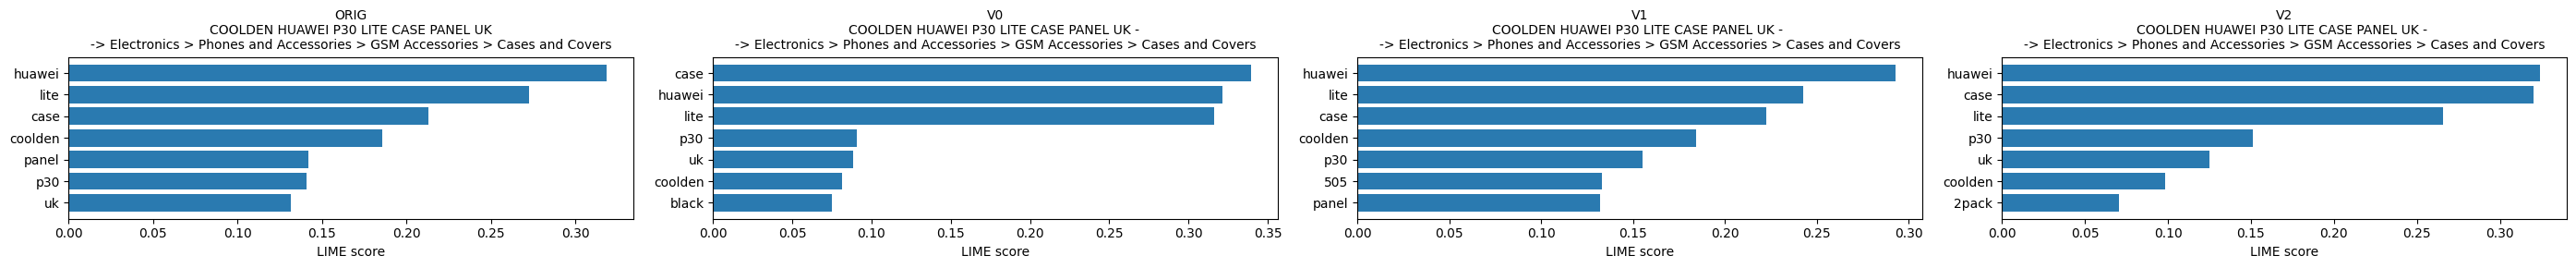

In [15]:
scores = []
for c in cases:
    ovs = c["lime"].get(1, {}).get("overlaps") or [1.0]
    scores.append(float(np.mean(ovs)))
idx = int(np.argmin(scores))
case = cases[idx]

n_plots = 1 + len(case["variants"])
fig, axes = plt.subplots(1, n_plots, figsize=(7 * n_plots, 3))
if n_plots == 1:
    axes = [axes]

orig_path = " > ".join(case["pred_orig"]["path"]) or "(empty)"
plot_word_importance(case["lime"][1]["exp_original"], k=7, ax=axes[0], title=f"ORIG\n{case['original_raw'][:40]}\n-> {orig_path}")
for i, (v, ev, pv) in enumerate(zip(case["variants_raw"], case["lime"][1]["exp_variants"], case["pred_variants"])):
    vpath = " > ".join(pv["path"]) or "(empty)"
    plot_word_importance(ev, k=7, ax=axes[i + 1], title=f"V{i}\n{v[:40]}\n-> {vpath}")
plt.tight_layout()
plt.show()

L1 flips found: 3 across 15 cases


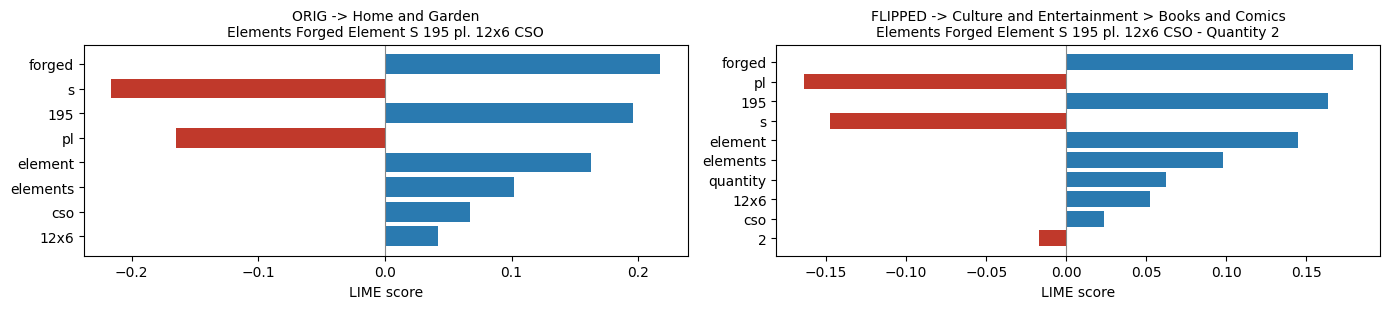

  injected words driving flip: quantity(+0.06), 2(-0.02)



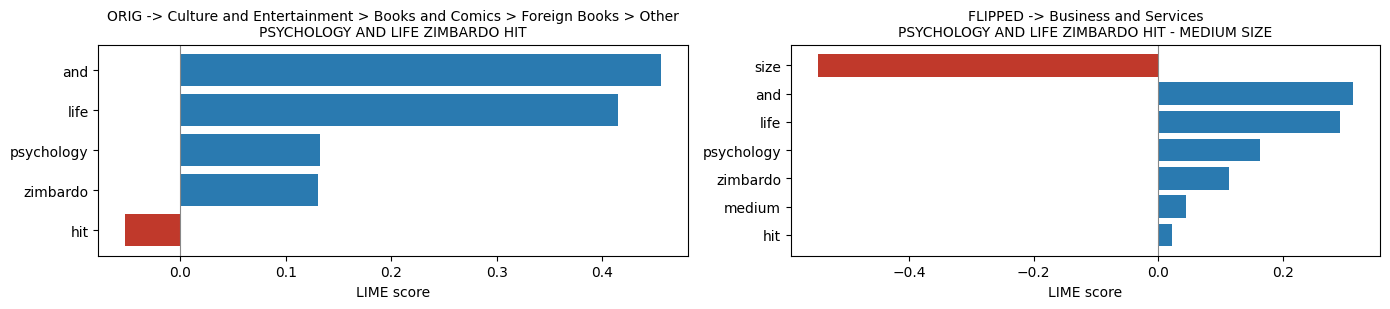

  injected words driving flip: size(-0.55), medium(+0.05)



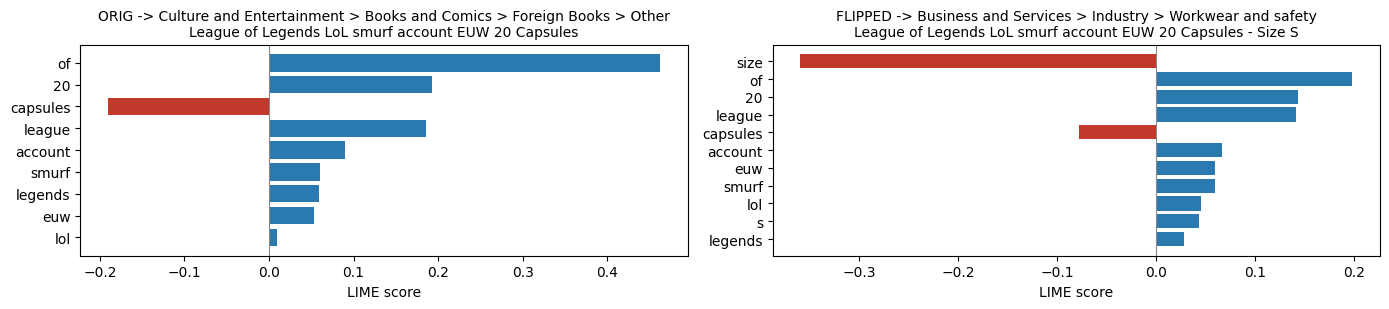

  injected words driving flip: size(-0.36), s(+0.04)



In [16]:
flip_plots = []
for ci, c in enumerate(cases):
    for vi, pv in enumerate(c["pred_variants"]):
        if not c["pred_orig"]["path"] or not pv["path"]:
            continue
        if pv["path"][0] != c["pred_orig"]["path"][0]:
            flip_plots.append((ci, vi))

print(f"L1 flips found: {len(flip_plots)} across {len(cases)} cases")

if not flip_plots:
    print("no flips in this sample -- rerun with larger CONSIST_N or different SEED")
else:
    for ci, vi in flip_plots[:4]:
        c = cases[ci]
        pv = c["pred_variants"][vi]
        exp_o = c["lime"][1]["exp_original"]
        exp_v = c["lime"][1]["exp_variants"][vi]

        orig_words = dict(zip(exp_o["words"], exp_o["scores"]))
        var_words = dict(zip(exp_v["words"], exp_v["scores"]))
        injected = [(w, var_words[w] - orig_words.get(w, 0.0)) for w in var_words if w not in orig_words]
        injected.sort(key=lambda x: abs(x[1]), reverse=True)

        fig, axes = plt.subplots(1, 2, figsize=(14, 3.2))
        plot_word_importance(
            exp_o, k=15, ax=axes[0],
            title=f"ORIG -> {' > '.join(c['pred_orig']['path'])}\n{c['original_raw'][:60]}",
        )
        plot_word_importance(
            exp_v, k=15, ax=axes[1],
            title=f"FLIPPED -> {' > '.join(pv['path'])}\n{c['variants_raw'][vi][:60]}",
        )
        plt.tight_layout()
        plt.show()
        if injected:
            top = ", ".join(f"{w}({s:+.2f})" for w, s in injected[:3])
            print(f"  injected words driving flip: {top}")
        print()


In [13]:
print("=== Accuracy@K per level ===")
acc_df.head()

=== Accuracy@K per level ===


,n_classes,n_samples,acc@1,acc@3,acc@5
level,,,,,
L1,12,2000,0.7440,0.8870,0.9345
L2,83,2000,0.5895,0.7095,0.7560
L3,639,1992,0.2877,0.3820,0.4257
L4,1853,1816,0.2043,0.2731,0.3144


In [14]:
print()
print("=== LIME faithfulness ===")
faith_df.head()


=== LIME faithfulness ===


,n,comp_mean,comp_std,suff_mean,suff_std,mono_mean,mono_std
level,,,,,,,
L1,25,0.611,0.235,-0.150,0.143,0.890,0.126
L2,25,0.498,0.250,-0.166,0.132,0.857,0.205


In [ ]:
print()
print("=== Consistency summary ===")
print(consist_df.to_markdown())

In [ ]:
print()
print("=== Per-case consistency detail ===")
print(per_case_df.to_markdown(index=False))